In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files

In [ ]:
files.upload()

Saving kaggle (4).json to kaggle (4).json


{'kaggle (4).json': b'{"username":"faridbazar","key":"ecd4d06767c708f8d1c12494d07f546c"}'}

In [ ]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d muratkokludataset/pistachio-image-dataset

Dataset URL: https://www.kaggle.com/datasets/muratkokludataset/pistachio-image-dataset
License(s): CC-BY-NC-SA-4.0
 94% 25.0M/26.7M [00:02<00:00, 14.3MB/s]
100% 26.7M/26.7M [00:02<00:00, 10.0MB/s]


In [ ]:
!unzip pistachio-image-dataset.zip -d pistachio

Archive:  pistachio-image-dataset.zip
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.arff  
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xls  
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xlsx  
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset_Citation_Request.txt  
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.arff  
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xls  
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xlsx  
  inflating: pistachio/Pistachio_Image_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset_Citation_Request.txt  
  inflating: pistach

In [ ]:
import pandas as pd


In [ ]:
import os

In [ ]:
df = pd.DataFrame(os.listdir("/content/pistachio/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio"), columns = ["x"])

In [ ]:
df["y"] = 1

In [ ]:
f = pd.DataFrame(os.listdir("/content/pistachio/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio"), columns=["x"])

In [ ]:
f["y"] = 0

In [ ]:
df2 = pd.concat([df,f], axis=0, ignore_index=True)

In [ ]:
df2

,x,y
0,kirmizi 1099.jpg,1
1,kirmizi 193.jpg,1
2,kirmizi 760.jpg,1
3,kirmizi 178.jpg,1
4,kirmizi 191.jpg,1
...,...,...
2143,siirt 402.jpg,0
2144,siirt 526.jpg,0
2145,siirt 162.jpg,0
2146,siirt 223.jpg,0


In [ ]:
def add_path(x):
  if "kirmizi" in x:
    return "/content/pistachio/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio/" + x
  else:
    return   "/content/pistachio/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio/" + x

In [ ]:
df2["x"] = df2["x"].apply(add_path)


In [ ]:
 df2

,x,y
0,/content/pistachio/Pistachio_Image_Dataset/Pis...,1
1,/content/pistachio/Pistachio_Image_Dataset/Pis...,1
2,/content/pistachio/Pistachio_Image_Dataset/Pis...,1
3,/content/pistachio/Pistachio_Image_Dataset/Pis...,1
4,/content/pistachio/Pistachio_Image_Dataset/Pis...,1
...,...,...
2143,/content/pistachio/Pistachio_Image_Dataset/Pis...,0
2144,/content/pistachio/Pistachio_Image_Dataset/Pis...,0
2145,/content/pistachio/Pistachio_Image_Dataset/Pis...,0
2146,/content/pistachio/Pistachio_Image_Dataset/Pis...,0


In [ ]:
import cv2
import numpy as np

In [ ]:
array_list = []
for image_path in df2['x']:
  img = cv2.imread(image_path)
  img = cv2.resize(img,(200,200))
  img = img/255

  array_list.append(img[:,:,::-1])
  del img
array_list = np.array(array_list)

In [ ]:
array_list.shape

(2148, 200, 200, 3)

In [ ]:
array_list = np.array(array_list,dtype=np.float32)

In [ ]:
2100 * 200 * 200 *3 *4

1008000000

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
array_list[400]

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

In [ ]:
array_list.shape

(2148, 200, 200, 3)

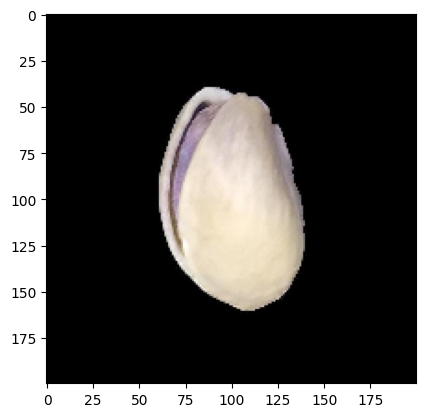

In [ ]:
plt.imshow(array_list[400]);

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
def onehot(arr):
  return np.eye(2)[arr]

In [ ]:
X = array_list
y = onehot(df2['y'].values)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3,random_state=101,shuffle=True)

In [ ]:
X_train[0]

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

In [ ]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
def init_weights(shape):
    init_random_dist = tf.truncated_normal(shape, stddev=0.1)
    return tf.Variable(init_random_dist)

def init_bias(shape):
    init_bias_vals = tf.constant(0.1, shape=shape)
    return tf.Variable(init_bias_vals)

def conv2d(x, W):
    return tf.nn.conv2d(x, W, strides=[1, 1, 1, 1],
                        padding='SAME')

def max_pool_2by2(x):
    return tf.nn.max_pool(x, ksize=[1, 2, 2, 1],
                          strides=[1, 2, 2, 1],
                          padding='SAME')

def convolutional_layer(input_x, shape):
    W = init_weights(shape)
    b = init_bias([shape[3]])
    return tf.nn.relu(conv2d(input_x, W) + b)

def normal_full_layer(input_layer, size):
    input_size = int(input_layer.get_shape()[1])
    W = init_weights([input_size, size])
    b = init_bias([size])
    return tf.matmul(input_layer, W) + b

In [ ]:
x = tf.placeholder(tf.float32,shape=[None,200,200,3])
y_true = tf.placeholder(tf.float32,shape=[None,2])

In [ ]:
hold_prob = tf.placeholder(tf.float32)

In [ ]:
convo_1 = convolutional_layer(x,shape=[9,9,3,32])
convo_1_pooling = max_pool_2by2(convo_1)

In [ ]:
convo_2 = convolutional_layer(convo_1_pooling,
                              shape=[7,7,32,64])
convo_2_pooling = max_pool_2by2(convo_2)

In [ ]:
convo_3 = convolutional_layer(convo_2_pooling,
                              shape=[5,5,64,64])
convo_3_pooling = max_pool_2by2(convo_3)

In [ ]:
convo_3_flat = tf.reshape(convo_3_pooling,[-1,25*25*64])

In [ ]:
25*25*64*4000

160000000

In [ ]:
full_layer_one = tf.nn.relu(normal_full_layer(convo_3_flat,
                                              4000))
full_one_dropout = tf.nn.dropout(full_layer_one,
                                 keep_prob=hold_prob)

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


In [ ]:
full_layer_two = tf.nn.relu(normal_full_layer(full_one_dropout,
                                              500))
full_two_dropout = tf.nn.dropout(full_layer_two,
                                 keep_prob=hold_prob)

In [ ]:
y_pred = normal_full_layer(full_two_dropout,2)

In [ ]:
cross_entropy = tf.reduce_mean(
    tf.nn.softmax_cross_entropy_with_logits(
        labels=y_true,logits=y_pred))

Instructions for updating:

Future major versions of TensorFlow will allow gradients to flow
into the labels input on backprop by default.

See `tf.nn.softmax_cross_entropy_with_logits_v2`.



In [ ]:
optimizer = tf.train.AdamOptimizer(learning_rate=0.001)
train = optimizer.minimize(cross_entropy)

In [ ]:
lateast_bid = 0

In [ ]:
def next_batch(batch_size = 100):
  global lateast_bid
  x_batch = X_train[lateast_bid:lateast_bid+batch_size]
  y_batch = y_train[lateast_bid:lateast_bid+batch_size]
  if lateast_bid+ batch_size <= len(X_train):
   lateast_bid  += batch_size
  else :
    lateast_bid = 0
  return x_batch , y_batch


In [ ]:
next_batch()

(array([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],
 
         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],
 
         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],
 
         ...,
 
         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],
 
         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],
 
         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],
 
 
        [

In [ ]:
init = tf.global_variables_initializer()

In [ ]:
lateast_bid = 0

In [ ]:
saver = tf.train.Saver()

In [ ]:
with tf.Session() as sess:
    sess.run(init)

    for i in range(500):
        batch = next_batch(100)
        sess.run(train, feed_dict={x: batch[0],
                                   y_true: batch[1],
                                   hold_prob: 0.5})

        # PRINT OUT A MESSAGE EVERY 100 STEPS
        if i%100 == 0:

            print('Currently on step {}'.format(i))
            print('Accuracy is:')
            # Test the Train Model
            matches = tf.equal(tf.argmax(y_pred,1),
                               tf.argmax(y_true,1))

            acc = tf.reduce_mean(tf.cast(matches,tf.float32))

            print(sess.run(acc,feed_dict={
                x: X_test,
                y_true: y_test,
                hold_prob:1.0}))
            print('\n')
    print('Currently on step {}'.format(i))
    print('Accuracy is:')
    # Test the Train Model
    matches = tf.equal(tf.argmax(y_pred,1),
                       tf.argmax(y_true,1))

    acc = tf.reduce_mean(tf.cast(matches,tf.float32))

    print(sess.run(acc,feed_dict={
        x: X_test,
        y_true: y_test,
        hold_prob:1.0}))
    saver.save(sess,'new_models/my_4th_model.ckpt')
    print('\n')

Currently on step 0
Accuracy is:
0.57984495


Currently on step 100
Accuracy is:
0.77829456


Currently on step 200
Accuracy is:
0.8620155


Currently on step 300
Accuracy is:
0.82325584


Currently on step 400
Accuracy is:
0.85426354


Currently on step 499
Accuracy is:
0.8651163




[1. 0.]


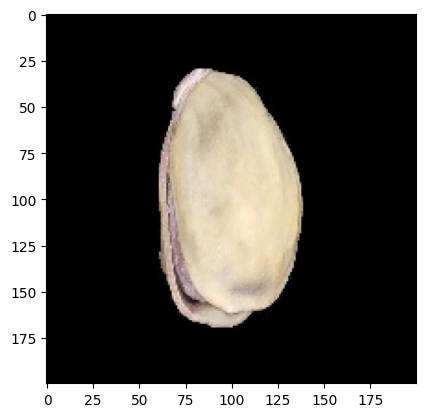

In [ ]:
print(y_test[0])
plt.imshow(X_test[0])

In [ ]:
with tf.Session() as sess:
#     sess.run(init)
    # Restore the model
    saver.restore(sess,tf.train.latest_checkpoint("new_models"))
    pred = sess.run(y_pred,feed_dict={x:[X_test[0]],hold_prob:1.0})

In [ ]:
pred.argmax()

1

In [ ]:
y_test

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])